In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Veriyi yükle
df = pd.read_csv('death rate of countries and its causes.csv')

# İlk bakış
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 6840 entries, 0 to 6839
Data columns (total 31 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   Entity                                    6840 non-null   str  
 1   Code                                      6150 non-null   str  
 2   Year                                      6840 non-null   int64
 3   Outdoor air pollution                     6840 non-null   int64
 4   High systolic blood pressure              6840 non-null   int64
 5   Diet high in sodium                       6840 non-null   int64
 6   Diet low in whole grains                  6840 non-null   int64
 7   Alochol use                               6840 non-null   int64
 8   Diet low in fruits                        6840 non-null   int64
 9   Unsafe water source                       6840 non-null   int64
 10  Secondhand smoke                          6840 non-null   int64
 11  Lo

In [2]:
# 'Code' sütunundaki eksiklikleri temizle veya doldur
df = df.dropna(subset=['Code']) 

# Sayısal olmayan sütunları ayırarak sadece analiz edilecek ölüm nedenlerine odaklan
death_causes = df.columns[3:] # 'Entity', 'Code', 'Year' dışındaki tüm sütunlar

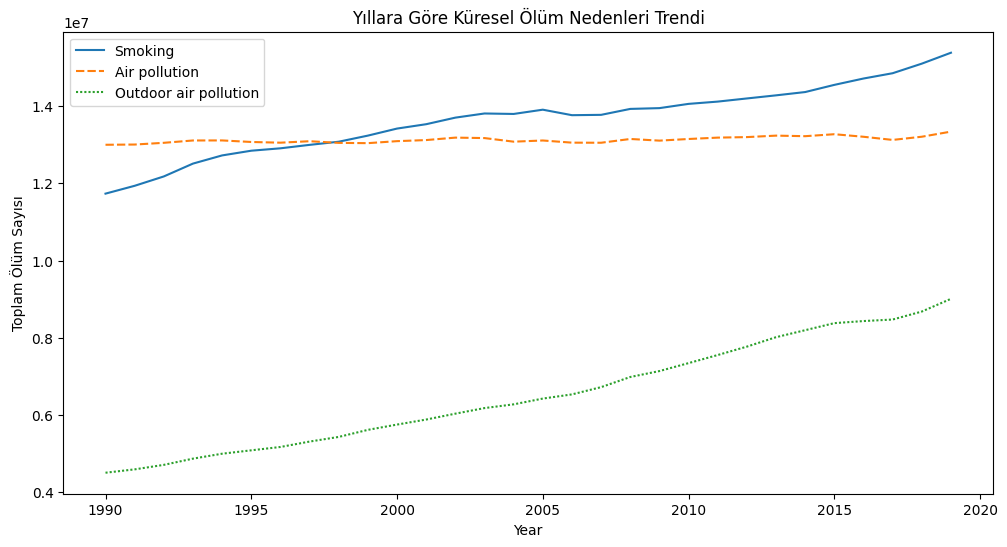

In [3]:
plt.figure(figsize=(12,6))
world_trend = df.groupby('Year')[['Smoking', 'Air pollution', 'Outdoor air pollution']].sum()
sns.lineplot(data=world_trend)
plt.title('Yıllara Göre Küresel Ölüm Nedenleri Trendi')
plt.ylabel('Toplam Ölüm Sayısı')
plt.show()

En son yıl: 2019
Top 5 Neden:
High systolic blood pressure    109162
Smoking                          86170
High body mass index             80118
High fasting plasma glucose      72369
Outdoor air pollution            44457
Name: 6149, dtype: int64


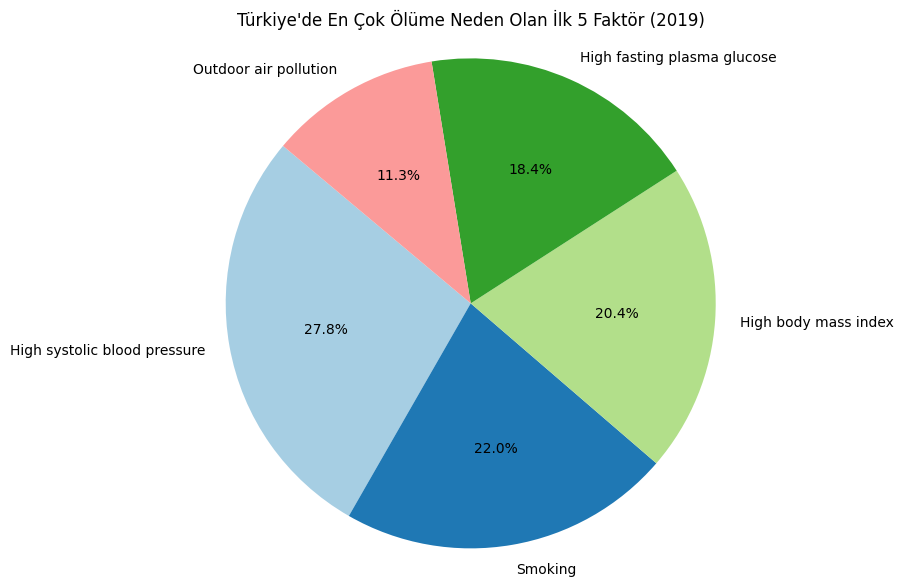

In [4]:
# Türkiye verisini filtrele
turkey_df = df[df['Entity'] == 'Turkey']

# En son yılı bul
latest_year = turkey_df['Year'].max()
turkey_latest = turkey_df[turkey_df['Year'] == latest_year]
causes = turkey_latest.drop(columns=['Entity', 'Code', 'Year'])
# Değerleri büyükten küçüğe sırala ve ilk 5'i al
top_5_causes = causes.iloc[0].sort_values(ascending=False).head(5)

# Grafik oluştur
plt.figure(figsize=(10, 7))
plt.pie(top_5_causes, labels=top_5_causes.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title(f'Türkiye\'de En Çok Ölüme Neden Olan İlk 5 Faktör ({latest_year})')
plt.axis('equal') 

print(f"En son yıl: {latest_year}")
print("Top 5 Neden:")
print(top_5_causes)

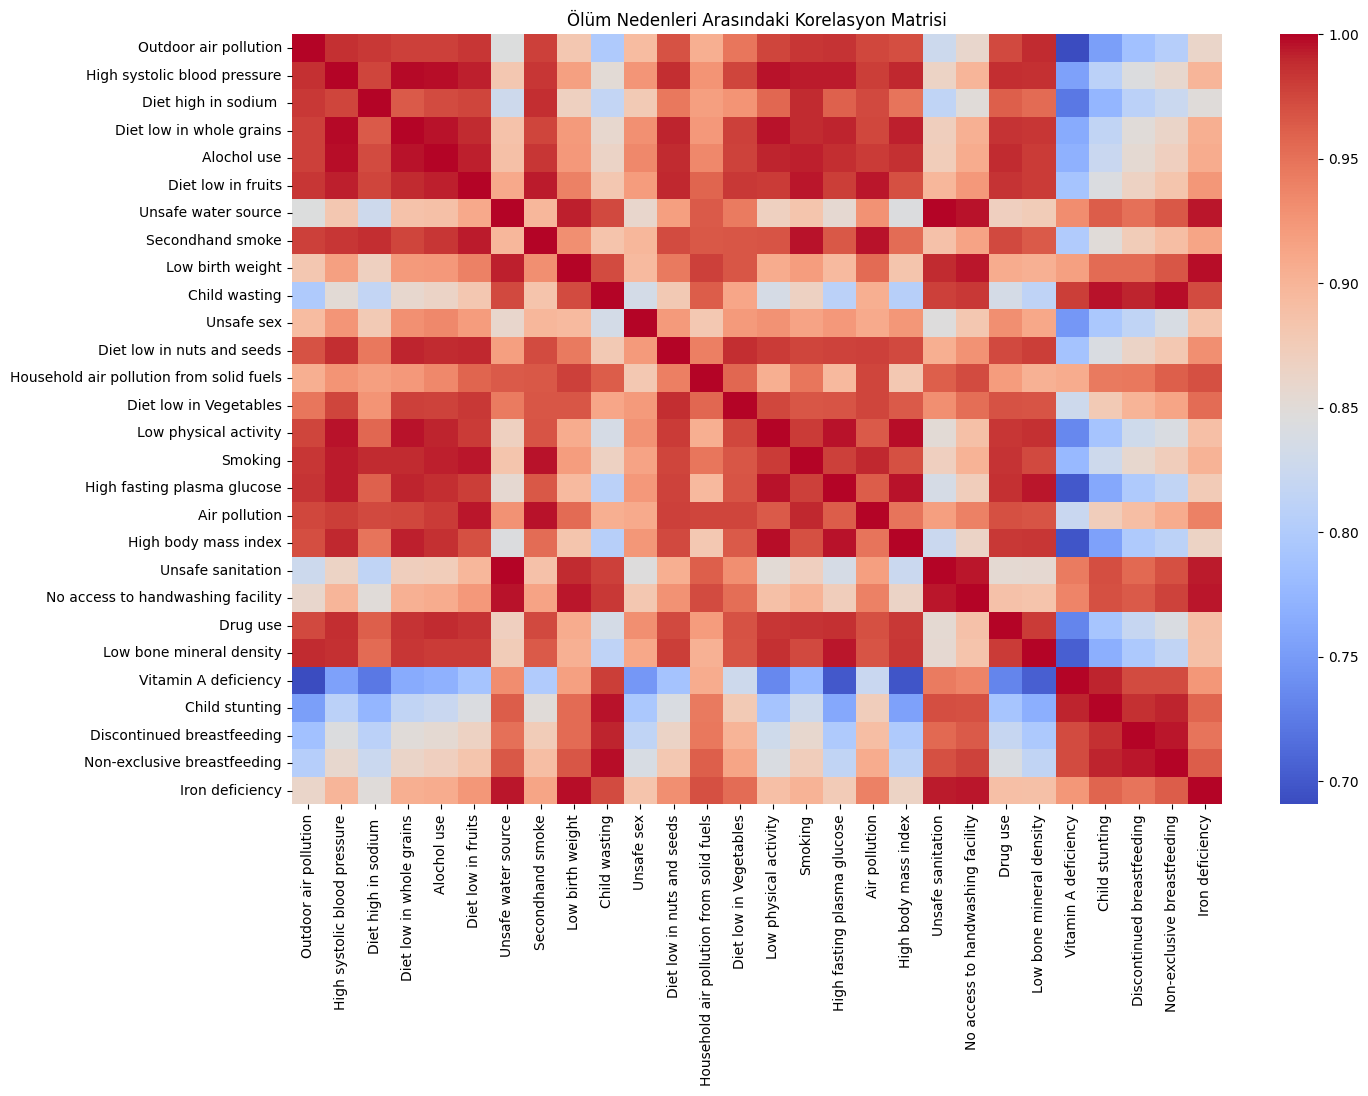

In [5]:
plt.figure(figsize=(15, 10))
corr = df[death_causes].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Ölüm Nedenleri Arasındaki Korelasyon Matrisi')
plt.show()

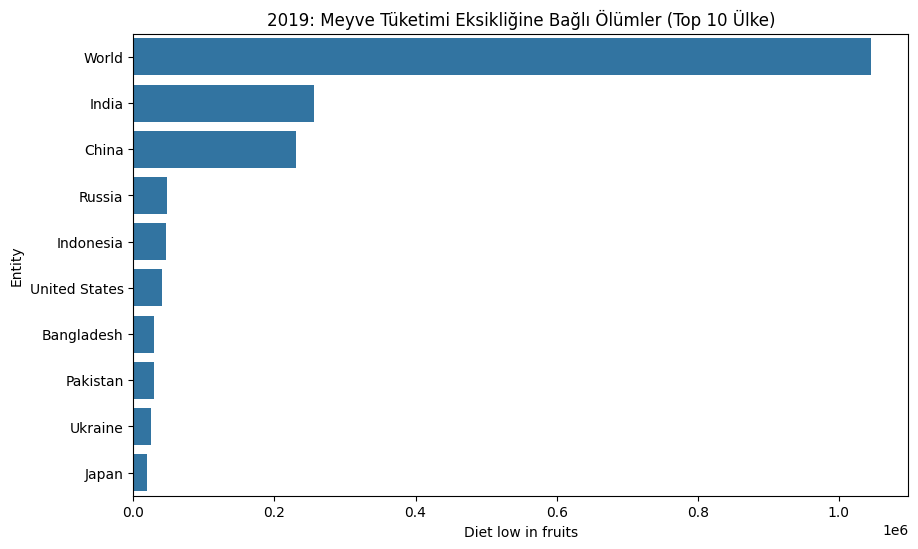

In [6]:
latest_year = df[df['Year'] == 2019]
top_10_diet = latest_year.nlargest(10, 'Diet low in fruits')

plt.figure(figsize=(10,6))
sns.barplot(data=top_10_diet, x='Diet low in fruits', y='Entity')
plt.title('2019: Meyve Tüketimi Eksikliğine Bağlı Ölümler (Top 10 Ülke)')
plt.show()

In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
from sklearn.metrics import mean_absolute_percentage_error
#Yüksek Tansiyon kaynaklı ölümleri tahmin et

X = df.drop(['Entity', 'Code', 'Year', 'High systolic blood pressure'], axis=1)
y = df['High systolic blood pressure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Eğitimi
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Tahmin ve Değerlendirme
y_pred = model.predict(X_test)
print(f"R2 Skoru: {r2_score(y_test, y_pred)}")
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Modelin Ortalama Yüzde Hatası: %{mape * 100:.2f}")

R2 Skoru: 0.9996136215015002
Modelin Ortalama Yüzde Hatası: %2.27


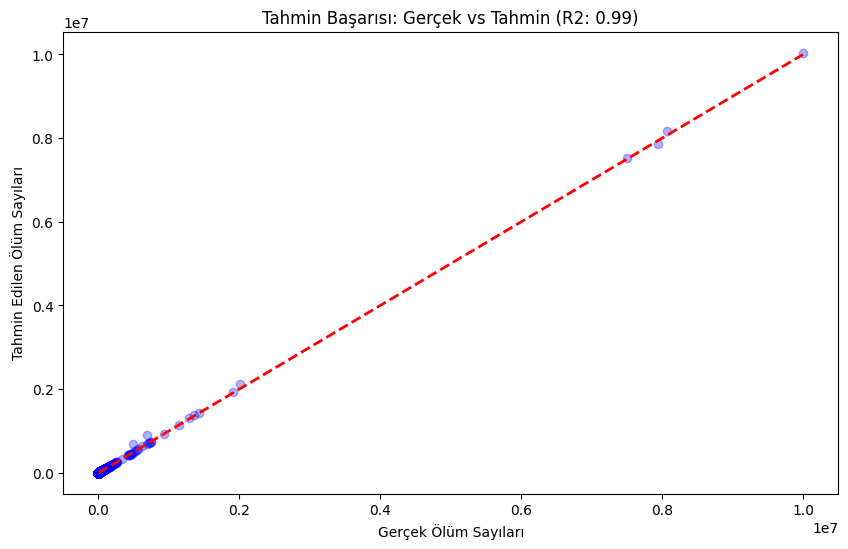

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Gerçek Ölüm Sayıları')
plt.ylabel('Tahmin Edilen Ölüm Sayıları')
plt.title('Tahmin Başarısı: Gerçek vs Tahmin (R2: 0.99)')
plt.show()

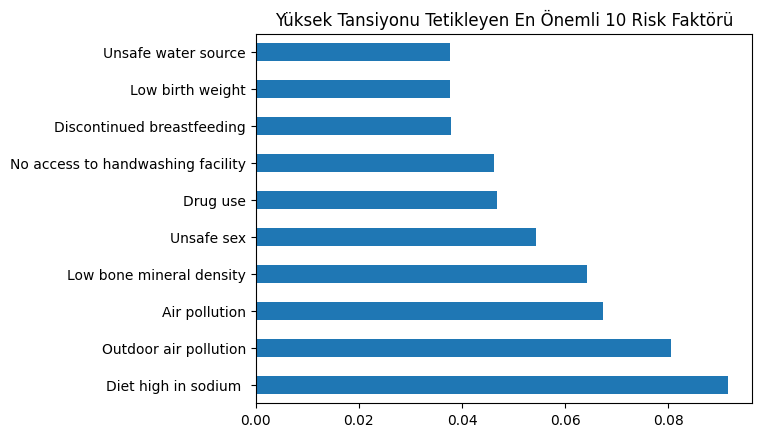

In [10]:
# Özellik Önem Düzeyi
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Yüksek Tansiyonu Tetikleyen En Önemli 10 Risk Faktörü')
plt.show()


 SAĞLIK PROFİLİ ÜLKE/YIL EŞLEŞTİRME SİSTEMİ

Lütfen yıllık tahmini ölüm etkisi değerlerini giriniz.

------------------------------
>>> EŞLEŞME SONUCU:
Girdiğiniz profil en çok şu kayıtla benzerlik gösterdi:
ÜLKE: Afghanistan
YIL  : 1998
Bu profildeki toplam risk yükü: 57273 birim.
------------------------------


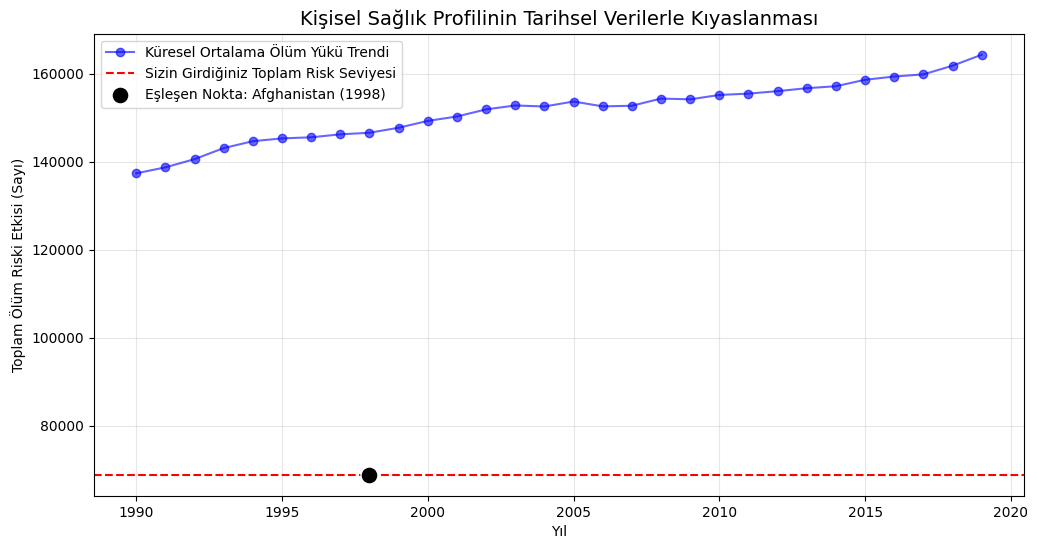

In [11]:
# Analiz edilecek sütunlar
features = ['Alochol use', 'Smoking', 'Air pollution', 'Iron deficiency']

def profil_eslestir():
    print("\n" + "="*50)
    print(" SAĞLIK PROFİLİ ÜLKE/YIL EŞLEŞTİRME SİSTEMİ")
    print("="*50)
    print("\nLütfen yıllık tahmini ölüm etkisi değerlerini giriniz.")
    
    try:
        u_alkol = float(input("\nAlkol Riski (Örn. 0 - 50.000 arası): "))
        u_sigara = float(input("Sigara Riski (Örn. 0 - 200.000 arası): "))
        u_hava = float(input("Hava Kirliliği Riski (Örn. 0 - 150.000 arası): "))
        u_demir = float(input("Demir Eksikliği Riski (Örn. 0 - 5.000 arası): "))
        
        user_vector = np.array([u_alkol, u_sigara, u_hava, u_demir])

        #  Benzerlik Hesapla 
        df_subset = df[features].values
        distances = np.linalg.norm(df_subset - user_vector, axis=1)
        
        # En yakın satırı bul
        closest_index = np.argmin(distances)
        match_row = df.iloc[closest_index]
        
        print("\n" + "-"*30)
        print(f">>> EŞLEŞME SONUCU:")
        print(f"Girdiğiniz profil en çok şu kayıtla benzerlik gösterdi:")
        print(f"ÜLKE: {match_row['Entity']}")
        print(f"YIL  : {int(match_row['Year'])}")
        print(f"Bu profildeki toplam risk yükü: {match_row[features].sum():.0f} birim.")
        print("-"*30)

        # Görselleştirme
        yearly_avg = df.groupby('Year')[features].mean().sum(axis=1)
        user_total = sum([u_alkol, u_sigara, u_hava, u_demir])

        plt.figure(figsize=(12, 6))
        # Küresel ortalama trendi
        plt.plot(yearly_avg.index, yearly_avg.values, label='Küresel Ortalama Ölüm Yükü Trendi', 
                 color='blue', marker='o', alpha=0.6)
        
        # Kullanıcının girdiği toplam değer
        plt.axhline(y=user_total, color='red', linestyle='--', label='Sizin Girdiğiniz Toplam Risk Seviyesi')
        
        # Eşleşen noktanın grafik üzerindeki yeri
        plt.scatter(match_row['Year'], user_total, color='black', s=150, edgecolors='white', 
                    zorder=5, label=f"Eşleşen Nokta: {match_row['Entity']} ({int(match_row['Year'])})")
        
        plt.title(f"Kişisel Sağlık Profilinin Tarihsel Verilerle Kıyaslanması", fontsize=14)
        plt.xlabel("Yıl")
        plt.ylabel("Toplam Ölüm Riski Etkisi (Sayı)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    except ValueError:
        print("\nHata! Lütfen sadece sayısal değerler giriniz.")

profil_eslestir()